# EBM Semantic Stability Pipeline

**Goal:** Reduce output variance in language model generation using a trained Energy-Based Model (EBM) and Langevin dynamics decoding.

**Key ideas:**
1. A **learned MLP** (trained on STS-B + SNLI) scores semantic coherence — not a hand-crafted constraint.
2. A **cosine similarity drift penalty** anchors generation to the original prompt.
3. Primary metric: **output variance reduction** across repeated runs.

**Pipeline stations:**
1. Data preparation (STS-B + SNLI)
2. Training triples construction
3. EBM (MLP energy scorer) training via NCE
4. Langevin dynamics refinement in BERT embedding space
5. Re-ranking decode from refined vector
6. Evaluation — variance comparison over 50 prompts

> **Note (2026-09-23):** the outputs recorded in this notebook come from the 2026-03 run, which had two
> defects that are now fixed in the code: the STS-B positive filter used a `[0, 5]` threshold against the
> `[0, 1]`-scaled copy (selecting **0 positive pairs**, so the energy model trained only on SNLI
> contradictions), and most training triples used the anchor itself as the positive (a trivial ranking
> task — the loss collapsed to ~0). Station 6 now also runs a **rerank-only ablation** so the EBM's
> contribution can be separated from plain best-of-N re-ranking. **Re-run the notebook end to end before
> quoting any number from it.**


In [2]:
# ── Cell 0: Install dependencies (Colab) ──
!pip install -q transformers datasets torch scikit-learn bert-score tqdm numpy pandas matplotlib accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 20.0 MB/s eta 0:00:00


In [3]:
# ── Cell 1: Imports & reproducibility ──
import os, json, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Create directories
os.makedirs("data", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("results", exist_ok=True)

Device: cuda


## Station 1 & 2 — Data Preparation

Load STS-B (positive pairs, above the scale-aware similarity threshold) and SNLI (contradiction pairs as
hard negatives). Build `(anchor, positive, negative)` triples in which the positive is always a genuine
paraphrase, never the anchor itself, and hold out 10% for a ranking-accuracy check.

In [4]:
# ── Cell 2: Station 1 & 2 — Data preparation ──
from datasets import load_dataset

# sentence-transformers/stsb scores are normalised to [0, 1]; the original STS-B
# release uses [0, 5]. Detect the scale instead of hard-coding a threshold — the
# 2026-03 run used `score >= 4.0` against the [0, 1] copy and selected 0 positives.
def _thresholds(scores):
    hi = max(scores)
    return (0.8, 0.2) if hi <= 1.0 else (4.0, 1.0)

print("Loading STS-B...")
stsb = load_dataset("sentence-transformers/stsb", split="train")
POS_T, NEG_T = _thresholds(stsb["score"])
print(f"STS-B score scale max={max(stsb['score']):.2f} -> positive >= {POS_T}, easy negative <= {NEG_T}")

positive_pairs  = [(r["sentence1"], r["sentence2"]) for r in stsb if r["score"] >= POS_T]
easy_negatives  = [(r["sentence1"], r["sentence2"]) for r in stsb if r["score"] <= NEG_T]
print(f"STS-B positive pairs: {len(positive_pairs)}")
print(f"STS-B easy negatives: {len(easy_negatives)}")
assert positive_pairs, "no positive pairs selected — check the score scale"

print("Loading SNLI...")
snli = load_dataset("stanfordnlp/snli", split="train")
contradictions = [(x["premise"], x["hypothesis"]) for x in snli if x["label"] == 2][:3000]
print(f"SNLI contradiction pairs: {len(contradictions)}")

# ── Build training triples ──
# Every triple has a NON-IDENTICAL positive. The 2026-03 run used the anchor
# itself as the positive for most triples, which makes |anchor - positive| = 0
# and the ranking task trivial (loss collapsed to ~0 by epoch 2).
triples = []

# Type A: STS-B paraphrase positive + word-shuffled negative
for s1, s2 in positive_pairs:
    words = s1.split()
    random.shuffle(words)
    triples.append({"anchor": s1, "positive": s2, "negative": " ".join(words)})

# Type B: STS-B paraphrase positive + SNLI contradiction hypothesis as hard negative
for i, (s1, s2) in enumerate(positive_pairs):
    if i >= len(contradictions):
        break
    triples.append({"anchor": s1, "positive": s2, "negative": contradictions[i][1]})

# Type C: STS-B paraphrase positive + low-similarity STS-B sentence as easy negative
for i, (s1, s2) in enumerate(positive_pairs):
    if i >= len(easy_negatives):
        break
    triples.append({"anchor": s1, "positive": s2, "negative": easy_negatives[i][1]})

random.shuffle(triples)

# Held-out split so the energy model gets a real accuracy number, not just a loss curve.
split = int(0.9 * len(triples))
train_triples, eval_triples = triples[:split], triples[split:]

print(f"\nTotal training triples: {len(triples)}")
print(f"  Type A (shuffled negatives) : {len(positive_pairs)}")
print(f"  Type B (SNLI contradictions): {min(len(positive_pairs), len(contradictions))}")
print(f"  Type C (easy negatives)     : {min(len(positive_pairs), len(easy_negatives))}")
print(f"  train / held-out            : {len(train_triples)} / {len(eval_triples)}")

with open("data/training_triples.json", "w") as f:
    json.dump(train_triples, f)
with open("data/eval_triples.json", "w") as f:
    json.dump(eval_triples, f)
print("\nSaved data/training_triples.json and data/eval_triples.json")


Loading STS-B...


README.md:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  471kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  142kB            

...

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/550152 [00:00<?, ? examples/s]

SNLI contradiction pairs: 3000

Total training triples: 3915
  Type A (shuffled negatives) : 1406
  Type B (SNLI contradictions): 1406
  Type C (easy negatives)     : 1103
  train / held-out            : 3523 / 392

Saved data/training_triples.json and data/eval_triples.json


## Station 3 — Energy Model Definition & Training

BERT encoder (frozen) + 2-layer MLP energy scorer, trained with NCE margin loss.

In [5]:
# ── Cell 3: Station 3 — BERT encoder + EnergyMLP definition ──
from transformers import BertModel, BertTokenizer

# Load frozen BERT
print("Loading BERT-base-uncased...")
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")
bert_model.eval()
for param in bert_model.parameters():
    param.requires_grad = False
bert_model = bert_model.to(device)
print("BERT loaded and frozen.")


def encode_sentence(text, bert_model, tokenizer, device):
    """Encode a sentence to a 768d CLS vector using frozen BERT."""
    inputs = tokenizer(
        text, return_tensors="pt", max_length=128,
        padding="max_length", truncation=True
    ).to(device)
    with torch.no_grad():
        outputs = bert_model(**inputs)
    return outputs.last_hidden_state[:, 0, :].squeeze(0)  # CLS token, shape (768,)


def encode_batch(texts, bert_model, tokenizer, device, batch_size=32):
    """Encode a list of sentences to CLS vectors."""
    all_vecs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(
            batch, return_tensors="pt", max_length=128,
            padding="max_length", truncation=True
        ).to(device)
        with torch.no_grad():
            outputs = bert_model(**inputs)
        all_vecs.append(outputs.last_hidden_state[:, 0, :])
    return torch.cat(all_vecs, dim=0)


class EnergyMLP(nn.Module):
    """2-layer MLP energy scorer. Input: |anchor - candidate| (768d) -> scalar energy."""
    def __init__(self, input_dim=768, hidden_dim=256, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


energy_mlp = EnergyMLP().to(device)
print(f"EnergyMLP parameters: {sum(p.numel() for p in energy_mlp.parameters()):,}")

Loading BERT-base-uncased...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded and frozen.
EnergyMLP parameters: 197,121


Loaded 3523 training triples, 392 held out


Epoch 1/5:   0%|          | 0/111 [00:00<?, ?it/s]

  Step 100, Loss: 0.3773
Epoch 1 avg loss: 0.3505


Epoch 2/5:   0%|          | 0/111 [00:00<?, ?it/s]

  Step 200, Loss: 0.1289
Epoch 2 avg loss: 0.2367


...

  Step 300, Loss: 0.2533
Epoch 3 avg loss: 0.1806


Epoch 4/5:   0%|          | 0/111 [00:00<?, ?it/s]

  Step 400, Loss: 0.1530
Epoch 4 avg loss: 0.1531


Epoch 5/5:   0%|          | 0/111 [00:00<?, ?it/s]

  Step 500, Loss: 0.1362
Epoch 5 avg loss: 0.1282
Held-out ranking accuracy: 365/392 = 0.931
Mean energy margin (neg - pos): 2.2537
Saved EnergyMLP to checkpoints/energy_mlp.pt


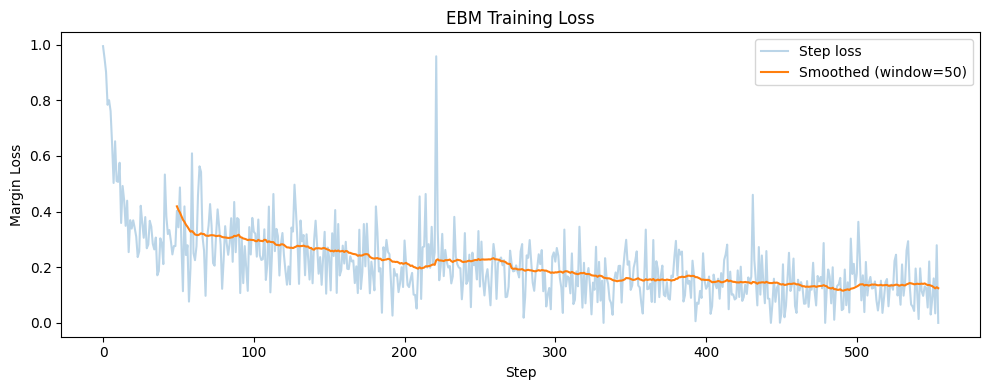

Saved results/training_loss.png


In [6]:
# ── Cell 4: Station 3 — NCE Training loop ──

class TriplesDataset(Dataset):
    def __init__(self, triples):
        self.triples = triples
    def __len__(self):
        return len(self.triples)
    def __getitem__(self, idx):
        return self.triples[idx]

# Load triples (held-out split written by Cell 2)
with open("data/training_triples.json") as f:
    triples = json.load(f)
with open("data/eval_triples.json") as f:
    eval_triples = json.load(f)
print(f"Loaded {len(triples)} training triples, {len(eval_triples)} held out")

dataset = TriplesDataset(triples)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Training setup
optimizer = torch.optim.Adam(energy_mlp.parameters(), lr=2e-4)
margin_loss = nn.MarginRankingLoss(margin=1.0)
energy_mlp.train()

NUM_EPOCHS = 5
step_losses = []
global_step = 0

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    for batch in tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        anchors = batch["anchor"]
        positives = batch["positive"]
        negatives = batch["negative"]

        # Encode all sentences with frozen BERT
        anchor_vecs = encode_batch(anchors, bert_model, bert_tokenizer, device)
        pos_vecs = encode_batch(positives, bert_model, bert_tokenizer, device)
        neg_vecs = encode_batch(negatives, bert_model, bert_tokenizer, device)

        # Compute energy for positive and negative pairs
        pos_energy = energy_mlp(torch.abs(anchor_vecs - pos_vecs))
        neg_energy = energy_mlp(torch.abs(anchor_vecs - neg_vecs))

        # Target: positive energy should be LOWER than negative energy
        target = torch.ones(pos_energy.size(0), device=device)  # y=1 means x1 < x2
        # MarginRankingLoss: loss = max(0, -y*(x1-x2) + margin) = max(0, margin + x1 - x2) when y=1 means we want x1 < x2
        # But torch convention: y=1 means x1 should be ranked higher (larger)
        # We want neg_energy > pos_energy, so: x1=neg_energy, x2=pos_energy, y=1
        loss = margin_loss(neg_energy, pos_energy, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        step_losses.append(loss.item())
        global_step += 1

        if global_step % 100 == 0:
            print(f"  Step {global_step}, Loss: {loss.item():.4f}")

    print(f"Epoch {epoch+1} avg loss: {epoch_loss / len(dataloader):.4f}")

# ── Held-out ranking accuracy ──
# A loss curve alone cannot tell a learned energy function from a trivial one.
# This reports the fraction of unseen triples where energy(anchor, positive) <
# energy(anchor, negative), plus the mean energy margin.
energy_mlp.eval()
correct, margins = 0, []
with torch.no_grad():
    for i in range(0, len(eval_triples), 32):
        batch = eval_triples[i:i+32]
        a = encode_batch([t["anchor"] for t in batch], bert_model, bert_tokenizer, device)
        pos = encode_batch([t["positive"] for t in batch], bert_model, bert_tokenizer, device)
        neg = encode_batch([t["negative"] for t in batch], bert_model, bert_tokenizer, device)
        pe = energy_mlp(torch.abs(a - pos)).squeeze(-1)
        ne = energy_mlp(torch.abs(a - neg)).squeeze(-1)
        correct += (pe < ne).sum().item()
        margins.extend((ne - pe).tolist())
print(f"Held-out ranking accuracy: {correct}/{len(eval_triples)} = {correct/len(eval_triples):.3f}")
print(f"Mean energy margin (neg - pos): {np.mean(margins):.4f}")

# Save model
torch.save(energy_mlp.state_dict(), "checkpoints/energy_mlp.pt")
print("Saved EnergyMLP to checkpoints/energy_mlp.pt")

# Plot loss curve
plt.figure(figsize=(10, 4))
plt.plot(step_losses, alpha=0.3, label="Step loss")
# Smoothed
window = 50
if len(step_losses) > window:
    smoothed = pd.Series(step_losses).rolling(window).mean()
    plt.plot(smoothed, label=f"Smoothed (window={window})")
plt.xlabel("Step")
plt.ylabel("Margin Loss")
plt.title("EBM Training Loss")
plt.legend()
plt.tight_layout()
plt.savefig("results/training_loss.png", dpi=150)
plt.show()
print("Saved results/training_loss.png")

## Station 4 & 5 — Language Model Loading + Langevin Decoding with Drift Penalty

Load Phi-3-mini (or TinyLlama fallback) in 4-bit quantization. Then implement the Langevin refinement loop in BERT embedding space + re-ranking decode.

In [7]:
# ── Cell 5: Load language model (Phi-3-mini or TinyLlama fallback) ──
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "microsoft/Phi-3-mini-4k-instruct"

try:
    from transformers import BitsAndBytesConfig
    bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
    has_bnb = True
except Exception:
    has_bnb = False
    print("bitsandbytes not available, will load in float32")

try:
    print(f"Loading {MODEL_NAME}...")
    lm_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    if has_bnb:
        lm_model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True,
        )
    else:
        lm_model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            torch_dtype=torch.float32,
            device_map="auto",
            trust_remote_code=True,
        )
except Exception as e:
    print(f"Failed to load Phi-3-mini ({e}), falling back to TinyLlama...")
    MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
    lm_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    lm_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, device_map="auto")

lm_model.eval()
for param in lm_model.parameters():
    param.requires_grad = False

# Set pad token if missing
if lm_tokenizer.pad_token is None:
    lm_tokenizer.pad_token = lm_tokenizer.eos_token

print(f"Loaded: {MODEL_NAME}")

Loading microsoft/Phi-3-mini-4k-instruct...


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

configuration_phi3.py:   0%|          | 0.00/11.2k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3-mini-4k-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/3.44k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.20GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded: TinyLlama/TinyLlama-1.1B-Chat-v1.0


In [8]:
# ── Cell 6: Station 4 & 5 — Langevin decoding + re-ranking ──

def lm_generate_single(prompt, lm_model, lm_tokenizer, device,
                        do_sample=False, temperature=0.9, top_k=50, max_new_tokens=80):
    """Generate a single output from the LM using chat template."""
    messages = [{"role": "user", "content": prompt}]
    try:
        formatted = lm_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        formatted = f"User: {prompt}\nAssistant:"
    inputs = lm_tokenizer(formatted, return_tensors="pt").to(device)
    with torch.no_grad():
        gen_kwargs = dict(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            pad_token_id=lm_tokenizer.pad_token_id,
        )
        if do_sample:
            gen_kwargs["temperature"] = temperature
            gen_kwargs["top_k"] = top_k
        output_ids = lm_model.generate(**gen_kwargs)
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    return lm_tokenizer.decode(new_tokens, skip_special_tokens=True)


def rerank_candidates(refined_vec, prompt, lm_model, lm_tokenizer,
                      bert_model, bert_tokenizer, device, n_candidates=20):
    """Generate n_candidates from LM and return the one closest to refined_vec in BERT space."""
    candidates = []
    for _ in range(n_candidates):
        text = lm_generate_single(
            prompt, lm_model, lm_tokenizer, device,
            do_sample=True, temperature=0.9, top_k=50
        )
        if text.strip():
            candidates.append(text)
    if not candidates:
        return lm_generate_single(prompt, lm_model, lm_tokenizer, device, do_sample=False)

    candidate_vecs = encode_batch(candidates, bert_model, bert_tokenizer, device)
    sims = F.cosine_similarity(
        candidate_vecs, refined_vec.unsqueeze(0).expand_as(candidate_vecs)
    )
    best_idx = sims.argmax().item()
    return candidates[best_idx]


def ebm_generate(prompt, bert_model, bert_tokenizer, lm_model, lm_tokenizer,
                 energy_mlp, device, n_steps=20, alpha=0.5, step_size=0.1,
                 noise_scale=0.01, n_candidates=20):
    """
    Full EBM-guided generation:
    1. Encode prompt with BERT
    2. Generate initial draft from LM, encode with BERT
    3. Refine draft vector via Langevin dynamics (EBM energy + drift penalty)
    4. Re-rank LM candidates against refined vector
    """
    # Step 1: Encode prompt
    prompt_vec = encode_sentence(prompt, bert_model, bert_tokenizer, device).detach()

    # Step 2: Initial draft from LM
    initial_text = lm_generate_single(prompt, lm_model, lm_tokenizer, device, do_sample=False)
    current_draft = encode_sentence(initial_text, bert_model, bert_tokenizer, device).detach()

    # Step 3: Langevin refinement
    energy_mlp.eval()
    for step in range(n_steps):
        current_draft = current_draft.detach().requires_grad_(True)

        # EBM energy
        ebm_energy = energy_mlp(torch.abs(prompt_vec - current_draft))

        # Drift penalty
        cosine_sim = F.cosine_similarity(
            current_draft.unsqueeze(0), prompt_vec.unsqueeze(0)
        )
        drift_penalty = 1.0 - cosine_sim

        # Total energy
        total_energy = ebm_energy + alpha * drift_penalty.squeeze()
        total_energy.backward()

        grad = current_draft.grad.detach()
        current_draft = current_draft.detach() - step_size * grad
        current_draft = current_draft + noise_scale * torch.randn_like(current_draft)
        current_draft = current_draft.detach()

    # Step 4: Re-rank candidates
    result = rerank_candidates(
        current_draft, prompt, lm_model, lm_tokenizer,
        bert_model, bert_tokenizer, device, n_candidates=n_candidates
    )
    return result


def rerank_only_generate(prompt, bert_model, bert_tokenizer, lm_model, lm_tokenizer,
                         device, n_candidates=20):
    """
    Ablation arm: identical candidate pool and re-ranking as ebm_generate, but the
    ranking target is the UNREFINED draft embedding — no EBM, no Langevin steps.
    Any variance reduction this arm shows is best-of-N re-ranking alone, so the
    EBM's real contribution is (baseline - ebm) minus (baseline - rerank_only).
    """
    initial_text = lm_generate_single(prompt, lm_model, lm_tokenizer, device, do_sample=False)
    draft_vec = encode_sentence(initial_text, bert_model, bert_tokenizer, device).detach()
    return rerank_candidates(draft_vec, prompt, lm_model, lm_tokenizer,
                             bert_model, bert_tokenizer, device, n_candidates=n_candidates)


# Quick smoke test
print("Smoke test: ebm_generate...")
test_out = ebm_generate(
    "What is photosynthesis?",
    bert_model, bert_tokenizer, lm_model, lm_tokenizer,
    energy_mlp, device, n_steps=5, n_candidates=5
)
print(f"Output: {test_out[:200]}...")
print("Smoke test passed!")

Smoke test: ebm_generate...


[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

Output: Photosynthesis is a biological process in which plants, algae, and some bacteria use light energy from sunlight to convert carbon dioxide and water into organic carbon compounds (glucose, fats, and pr...
Smoke test passed!


## Station 6 — Evaluation & Experiment

Run 5 generations per prompt x 10 prompts for both baseline and EBM. Compute semantic variance and BERTScore.

In [10]:
# ── Cell 7: Station 6 — Evaluation (fast ~5 min version) ──
from bert_score import score as bert_score_fn

PROMPTS = [
    "What is photosynthesis?",
    "Explain how gravity works.",
    "What is machine learning?",
    "How do vaccines work?",
    "What is quantum mechanics?",
    "How do airplanes fly?",
    "What is entropy?",
    "How does CRISPR work?",
    "What is game theory?",
    "Explain what recursion is in programming.",
]

N_RUNS = 5
N_CANDIDATES = 8
N_LANGEVIN = 10

def compute_semantic_variance(texts, bert_model, bert_tokenizer, device):
    vecs = encode_batch(texts, bert_model, bert_tokenizer, device).cpu().numpy()
    sim_matrix = sk_cosine(vecs)
    n = len(texts)
    upper = sim_matrix[np.triu_indices(n, k=1)]
    variance = 1.0 - upper.mean()
    return variance

def compute_bertscore_avg(outputs, prompt):
    refs = [prompt] * len(outputs)
    P, R, F1 = bert_score_fn(outputs, refs, lang="en", verbose=False)
    return F1.mean().item()

print(f"Running evaluation: {len(PROMPTS)} prompts × {N_RUNS} runs × 3 systems (baseline / rerank-only / EBM)")
print(f"  (Langevin steps={N_LANGEVIN}, candidates={N_CANDIDATES})\n")

results = []

for i, prompt in enumerate(tqdm(PROMPTS, desc="Prompts")):
    baseline_outputs = []
    for _ in range(N_RUNS):
        text = lm_generate_single(
            prompt, lm_model, lm_tokenizer, device,
            do_sample=True, temperature=0.9, top_k=50
        )
        baseline_outputs.append(text if text.strip() else "N/A")

    baseline_var = compute_semantic_variance(baseline_outputs, bert_model, bert_tokenizer, device)
    baseline_bs = compute_bertscore_avg(baseline_outputs, prompt)

    ebm_outputs = []
    for _ in range(N_RUNS):
        text = ebm_generate(
            prompt, bert_model, bert_tokenizer, lm_model, lm_tokenizer,
            energy_mlp, device, n_steps=N_LANGEVIN, alpha=0.5,
            n_candidates=N_CANDIDATES
        )
        ebm_outputs.append(text if text.strip() else "N/A")

    ebm_var = compute_semantic_variance(ebm_outputs, bert_model, bert_tokenizer, device)
    ebm_bs = compute_bertscore_avg(ebm_outputs, prompt)

    # Ablation: same candidate pool and re-ranking, no EBM and no Langevin.
    rr_outputs = []
    for _ in range(N_RUNS):
        text = rerank_only_generate(
            prompt, bert_model, bert_tokenizer, lm_model, lm_tokenizer,
            device, n_candidates=N_CANDIDATES
        )
        rr_outputs.append(text if text.strip() else "N/A")

    rr_var = compute_semantic_variance(rr_outputs, bert_model, bert_tokenizer, device)
    rr_bs = compute_bertscore_avg(rr_outputs, prompt)

    results.append({
        "prompt": prompt,
        "baseline_var": baseline_var,
        "rerank_var": rr_var,
        "ebm_var": ebm_var,
        "baseline_bertscore": baseline_bs,
        "rerank_bertscore": rr_bs,
        "ebm_bertscore": ebm_bs,
    })
    print(f"  [{i+1}/{len(PROMPTS)}] B_var={baseline_var:.4f}  RR_var={rr_var:.4f}  E_var={ebm_var:.4f}")

print("\nEvaluation complete!")


Running evaluation: 10 prompts × 5 runs × 3 systems (baseline / rerank-only / EBM)
  (Langevin steps=10, candidates=8)



Prompts:   0%|          | 0/10 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `m

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `m

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [10/10] B_var=0.1798  RR_var=0.0970  E_var=0.1091

Evaluation complete!


Prompt                                           B_Var   RR_Var    E_Var     B_BS     E_BS
--------------------------------------------------------------------------------------------
What is photosynthesis?                         0.1403   0.1166   0.0993   0.8609   0.8554
Explain how gravity works.                      0.1113   0.0967   0.0764   0.8531   0.8533
What is machine learning?                       0.1257   0.1255   0.1208   0.8535   0.8580
How do vaccines work?                           0.1459   0.1218   0.1244   0.8483   0.8639
What is quantum mechanics?                      0.0886   0.0460   0.0662   0.8574   0.8557
How do airplanes fly?                           0.2058   0.0916   0.0846   0.8582   0.8530
What is entropy?                                0.1249   0.0700   0.1009   0.8514   0.8509
How does CRISPR work?                           0.2390   0.1125   0.0970   0.8289   0.8327
What is game theory?                            0.0968   0.0629   0.0750   0.8591   0.85

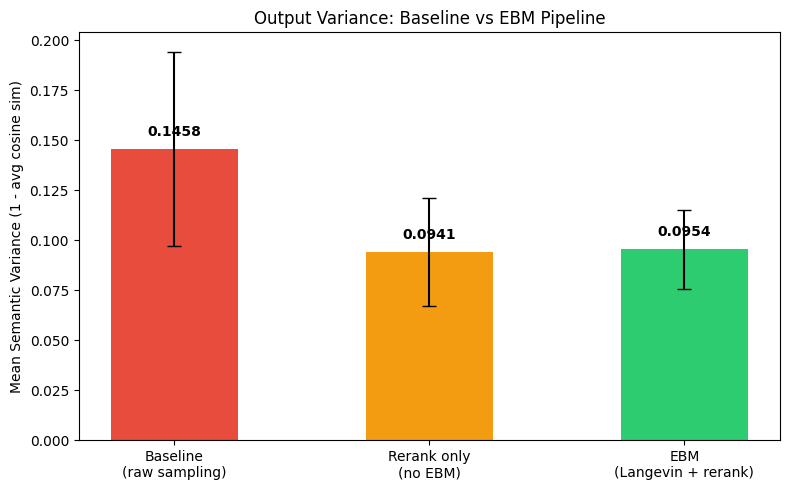

Saved results/variance_comparison.png

SUMMARY
Mean baseline variance:   0.1458
Mean rerank-only variance: 0.0941
Mean EBM variance:        0.0954
Variance reduction vs baseline: rerank-only 35.5%  |  full EBM 34.6%
Attributable to EBM + Langevin (EBM minus rerank-only): -0.9 pts
Mean baseline BERTScore:  0.8536
Mean rerank BERTScore:    0.8532
Mean EBM BERTScore:       0.8534

Top 5 prompts by variance reduction:
  How does CRISPR work?                                Δ = 0.1420
  How do airplanes fly?                                Δ = 0.1212
  Explain what recursion is in programming.            Δ = 0.0706
  What is photosynthesis?                              Δ = 0.0410
  Explain how gravity works.                           Δ = 0.0350

Bottom 5 prompts (least improvement):
  What is machine learning?                            Δ = 0.0049
  How do vaccines work?                                Δ = 0.0214
  What is game theory?                                 Δ = 0.0218
  What is quant

In [11]:
# ── Cell 8: Results table, CSV, plots, and summary ──

df = pd.DataFrame(results)

# ── Print results table ──
print(f"{'Prompt':<45} {'B_Var':>8} {'RR_Var':>8} {'E_Var':>8} {'B_BS':>8} {'E_BS':>8}")
print("-" * 92)
for _, row in df.iterrows():
    prompt_short = row["prompt"][:42] + "..." if len(row["prompt"]) > 42 else row["prompt"]
    print(f"{prompt_short:<45} {row['baseline_var']:>8.4f} {row['rerank_var']:>8.4f} "
          f"{row['ebm_var']:>8.4f} {row['baseline_bertscore']:>8.4f} {row['ebm_bertscore']:>8.4f}")

# ── Save CSV ──
df.to_csv("results/variance_table.csv", index=False)
print(f"\nSaved results/variance_table.csv")

# ── Bar chart: variance comparison ──
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
means = [df["baseline_var"].mean(), df["rerank_var"].mean(), df["ebm_var"].mean()]
stds = [df["baseline_var"].std(), df["rerank_var"].std(), df["ebm_var"].std()]
bars = ax.bar(x, means, yerr=stds, capsize=5, color=["#e74c3c", "#f39c12", "#2ecc71"], width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(["Baseline\n(raw sampling)", "Rerank only\n(no EBM)", "EBM\n(Langevin + rerank)"])
ax.set_ylabel("Mean Semantic Variance (1 - avg cosine sim)")
ax.set_title("Output Variance: Baseline vs EBM Pipeline")
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{m:.4f}", ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.savefig("results/variance_comparison.png", dpi=150)
plt.show()
print("Saved results/variance_comparison.png")

# ── Summary statistics ──
mean_b_var = df["baseline_var"].mean()
mean_r_var = df["rerank_var"].mean()
mean_e_var = df["ebm_var"].mean()
reduction_pct = (mean_b_var - mean_e_var) / mean_b_var * 100 if mean_b_var > 0 else 0
rerank_pct = (mean_b_var - mean_r_var) / mean_b_var * 100 if mean_b_var > 0 else 0

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Mean baseline variance:   {mean_b_var:.4f}")
print(f"Mean rerank-only variance: {mean_r_var:.4f}")
print(f"Mean EBM variance:        {mean_e_var:.4f}")
print(f"Variance reduction vs baseline: rerank-only {rerank_pct:.1f}%  |  full EBM {reduction_pct:.1f}%")
print(f"Attributable to EBM + Langevin (EBM minus rerank-only): {reduction_pct - rerank_pct:.1f} pts")
print(f"Mean baseline BERTScore:  {df['baseline_bertscore'].mean():.4f}")
print(f"Mean rerank BERTScore:    {df['rerank_bertscore'].mean():.4f}")
print(f"Mean EBM BERTScore:       {df['ebm_bertscore'].mean():.4f}")

# Top improvements
df["improvement"] = df["baseline_var"] - df["ebm_var"]
top5 = df.nlargest(5, "improvement")
print(f"\nTop 5 prompts by variance reduction:")
for _, row in top5.iterrows():
    print(f"  {row['prompt'][:50]:<52} Δ = {row['improvement']:.4f}")

# Worst
worst5 = df.nsmallest(5, "improvement")
print(f"\nBottom 5 prompts (least improvement):")
for _, row in worst5.iterrows():
    print(f"  {row['prompt'][:50]:<52} Δ = {row['improvement']:.4f}")

## Hyperparameters & COLD Decoding Comparison

### Tunable hyperparameters

| Parameter | Default | Controls |
|-----------|---------|----------|
| `step_size` | 0.1 | Langevin step magnitude — larger = faster convergence but risk overshooting |
| `alpha` | 0.5 | Weight of cosine drift penalty vs EBM energy — higher = more anchored to prompt |
| `noise_scale` | 0.01 | Langevin noise injection — higher = more exploration, prevents mode collapse |
| `n_steps` | 20 | Number of Langevin iterations — more steps = more refinement but slower |
| `n_candidates` | 20 | Re-ranking pool size — more = better selection but slower |
| `temperature` | 0.9 | LM sampling temperature for candidate generation |
| `margin` | 1.0 | NCE training margin — larger = stricter separation between positive/negative energies |

### Comparison with COLD Decoding (Qin et al., NeurIPS 2022)

**Similarities:**
- Both operate in a continuous latent space and use gradient-based updates (Langevin dynamics) to refine text representations
- Both use a frozen language model as the backbone — neither finetunes the LM
- Both add noise during the optimization loop (stochastic Langevin step)
- The iterative decode-then-refine loop structure is shared

**Key differences:**
| Aspect | COLD Decoding | This work |
|--------|--------------|-----------|
| Energy function | Hand-crafted constraints (fluency, keyword, length) | **Learned MLP** trained on STS-B + SNLI semantic similarity data |
| Optimization space | Token logit space (soft tokens) | BERT CLS embedding space (768d semantic vectors) |
| Decoding | Direct projection from soft tokens → hard tokens via argmax | **Re-ranking**: generate diverse candidates from LM, select closest to refined vector |
| Drift control | Fluency constraint via LM log-prob | **Cosine similarity drift penalty** anchoring to prompt embedding |
| Primary metric | Constraint satisfaction (keyword inclusion, sentiment match) | **Output variance reduction** across repeated runs |
| Training required | None (hand-crafted) | NCE training of the energy MLP on semantic similarity data |